# Modèle LightGBM

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OrdinalEncoder
import lightgbm as lgb
import zipfile
import os
import matplotlib.pyplot as plt

## 1. Chargement des fichiers

In [ ]:
ZIP_FILE_PATH = 'data/data.zip'
print(f"Lecture des fichiers depuis l'archive : {ZIP_FILE_PATH}")
try:
    with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zf:
        try:
            train_df = pd.read_csv(zf.open('train.csv'))
        except KeyError:
            train_df = pd.read_csv(zf.open(os.path.join('data', 'train.csv')))
        try:
            test_df = pd.read_csv(zf.open('test.csv'))
        except KeyError:
            test_df = pd.read_csv(zf.open(os.path.join('data', 'test.csv')))
        try:
            sample_submission = pd.read_csv(zf.open('sample_submission.csv'))
        except KeyError:
            sample_submission = pd.read_csv(zf.open(os.path.join('data', 'sample_submission.csv')))

    print("Fichiers chargés avec succès depuis le ZIP.")
except FileNotFoundError:
    print(f"Erreur: Le fichier ZIP n'a pas été trouvé à l'emplacement : {ZIP_FILE_PATH}")
    raise


Lecture des fichiers depuis l'archive : data/data.zip
Fichiers chargés avec succès depuis le ZIP.


## 2. Pre-processing

In [ ]:
TARGETS = ['satisfaction', 'wip', 'investissement']
X = train_df.drop(columns=['id'] + TARGETS, errors='ignore')
y = train_df[TARGETS]
X_test_final = test_df.drop(columns=['id'], errors='ignore')
input_cols = X.columns.tolist()
for col in input_cols:
    X[col] = X[col].astype('category')
    X_test_final[col] = X_test_final[col].astype('category')
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Le modèle

In [ ]:
params = {
    "objective": "regression", 
    "metric": "rmse",
    "boosting_type": "gbdt",
    "num_leaves": 128,
    "learning_rate": 0.005,
    "max_depth": -1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "verbose": -1,
    "n_jobs": -1,
    "seed": 42
}
N_ESTIMATORS = 10000
EARLY_STOPPING_ROUNDS = 500
predictions = {}
predictions_reduced = {}

## 4. Prédictions

In [ ]:
def custom_hit_rate_metric_lgbm(y_pred, y_true, delta=0.05):
    if isinstance(y_true, lgb.Dataset):
        y_true = y_true.get_label()
    residuals = np.abs(y_true - y_pred)
    hits = np.sum(residuals <= delta)
    score = hits / len(y_true)
    return 'hit_rate_0.05', score, True

In [ ]:
for i, target in enumerate(TARGETS):
    print(f"\nEntraînement pour la cible : {target}")
    lgb_train = lgb.Dataset(X_train, y_train[target], categorical_feature=input_cols)
    lgb_valid = lgb.Dataset(X_valid, y_valid[target], categorical_feature=input_cols, reference=lgb_train)
    feval_list = None
    if target == 'satisfaction':
        feval_list = [custom_hit_rate_metric_lgbm]
        print(f"  Utilisation de la métrique personnalisée 'hit_rate_0.05' pour l'arrêt anticipé.")
    model = lgb.train(
        params,
        lgb_train,
        num_boost_round=N_ESTIMATORS,
        valid_sets=[lgb_train, lgb_valid],
        valid_names=["train", "valid"],
        feval=feval_list, 
        callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=True)] 
    )
    predictions[target] = model.predict(X_test_final, num_iteration=model.best_iteration)
    if target == 'satisfaction':
        y_pred_valid = model.predict(X_valid, num_iteration=model.best_iteration)
        _, final_score, _ = custom_hit_rate_metric_lgbm(y_pred_valid, y_valid[target].values)
        print(f"Score final sur l'ensemble de validation (hit_rate @0.05): {final_score:.4f}")
    else:
        y_pred_valid = model.predict(X_valid, num_iteration=model.best_iteration)
        mae_valid = np.mean(np.abs(y_valid[target].values - y_pred_valid))
        print(f"MAE sur l'ensemble de validation pour {target}: {mae_valid:.4f}")


Entraînement pour la cible : satisfaction
  Utilisation de la métrique personnalisée 'hit_rate_0.05' pour l'arrêt anticipé.
Training until validation scores don't improve for 500 rounds
Early stopping, best iteration is:
[7181]	train's rmse: 0.0308265	train's hit_rate_0.05: 0.904736	valid's rmse: 0.0496359	valid's hit_rate_0.05: 0.775047
Score final sur l'ensemble de validation (hit_rate @0.05): 0.7750

Entraînement pour la cible : wip
Training until validation scores don't improve for 500 rounds
Did not meet early stopping. Best iteration is:
[10000]	train's rmse: 1.12793e+06	valid's rmse: 2.05213e+06
MAE sur l'ensemble de validation pour wip: 1240391.4134

Entraînement pour la cible : investissement
Training until validation scores don't improve for 500 rounds
Did not meet early stopping. Best iteration is:
[10000]	train's rmse: 35.2399	valid's rmse: 90.1997
MAE sur l'ensemble de validation pour investissement: 51.9276


## 5. Sélection des meilleures features

In [ ]:
feature_names = model.feature_name()
importances = model.feature_importance(importance_type='gain') 
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})
importance_df = importance_df.sort_values(by='importance', ascending=False).reset_index(drop=True)

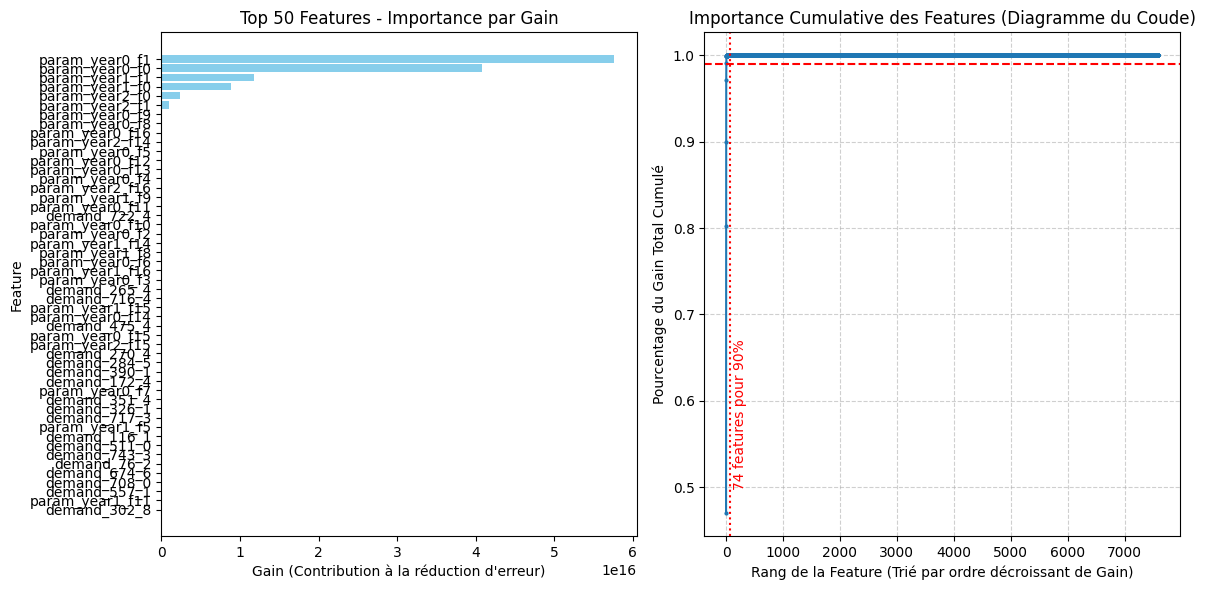


74 features sont nécessaires pour capturer 99.99% du gain total du modèle.


In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
N_DISPLAY = 50
plt.barh(importance_df['feature'].head(N_DISPLAY), importance_df['importance'].head(N_DISPLAY), color='skyblue')
plt.gca().invert_yaxis()
plt.title(f'Top {N_DISPLAY} Features - Importance par Gain')
plt.xlabel('Gain (Contribution à la réduction d\'erreur)')
plt.ylabel('Feature')
plt.subplot(1, 2, 2)
importance_df['cumulative_gain'] = importance_df['importance'].cumsum()
importance_df['normalized_cumulative_gain'] = importance_df['cumulative_gain'] / importance_df['importance'].sum()
plt.plot(importance_df.index + 1, importance_df['normalized_cumulative_gain'], marker='o', markersize=2, linestyle='-')
plt.title('Importance Cumulative des Features (Diagramme du Coude)')
plt.xlabel('Rang de la Feature (Trié par ordre décroissant de Gain)')
plt.ylabel('Pourcentage du Gain Total Cumulé')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(y=0.99, color='r', linestyle='--', label='99.9% du Gain Total')
idx_99 = importance_df[importance_df['normalized_cumulative_gain'] >= 0.9999].index[0] + 1
plt.axvline(x=idx_99, color='r', linestyle=':')
plt.text(idx_99 + 50, 0.5, f'{idx_99} features pour 90%', color='r', rotation=90)
plt.tight_layout()
plt.show()
print(f"\n{idx_99} features sont nécessaires pour capturer 99.99% du gain total du modèle.")

## 6. Entrainement Modèle sur Top 400 features 

In [ ]:
N_TOP_FEATURES = 400
ids = train_df['id']
X = train_df.drop(columns=['id'] + TARGETS, errors='ignore')
y = train_df[TARGETS]
X_test_final = test_df.drop(columns=['id'], errors='ignore')
top_features_df = importance_df.head(N_TOP_FEATURES)
top_features = top_features_df['feature'].tolist()
print("Conversion des colonnes en type 'category'")
for col in X.columns:
    if X[col].dtype == 'object' or (X[col].nunique() < 20):
        X[col] = X[col].astype('category')
        if col in X_test_final.columns:
            X_test_final[col] = X_test_final[col].astype('category')
indices = np.arange(len(X))
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42, shuffle=True)
X_train = X.iloc[train_idx]
y_train = y.iloc[train_idx]
X_valid = X.iloc[val_idx]
y_valid = y.iloc[val_idx]
X_train_reduced = X_train[top_features]
X_valid_reduced = X_valid[top_features]
X_test_final_reduced = X_test_final[top_features]
val_ids = ids.iloc[val_idx].values
test_ids = test_df['id'].values
print(f"\nNombre total de features initiales : {len(feature_names)}")
print(f"Nombre de features sélectionnées : {len(top_features)}")

Conversion des colonnes en type 'category'...

Nombre total de features initiales : 7591
Nombre de features sélectionnées : 400


In [ ]:
stacking_df = pd.DataFrame({'id': val_ids})
submission_df = pd.DataFrame({'id': test_ids})
for col in TARGETS:
    stacking_df[f'true_{col}'] = y_valid[col].values
models_dict = {}
for i, target in enumerate(TARGETS):
    print(f"\nEntraînement pour la cible : {target}")
    lgb_train = lgb.Dataset(X_train_reduced, y_train[target], categorical_feature=top_features)
    lgb_valid = lgb.Dataset(X_valid_reduced, y_valid[target], categorical_feature=top_features, reference=lgb_train)
    feval_list = None
    if target == 'satisfaction':
        feval_list = [custom_hit_rate_metric_lgbm]
        print(f"  Utilisation de la métrique personnalisée 'hit_rate_0.05' pour l'arrêt anticipé.")
    # Entraînement 
    model = lgb.train(
        params,
        lgb_train,
        num_boost_round=N_ESTIMATORS,
        valid_sets=[lgb_train, lgb_valid],
        valid_names=["train", "valid"],
        feval=feval_list, 
        callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=True)] 
    )
    models_dict[target] = model
    # Prédictions Validation Pour le Stacking
    print(f"  - Génération des prédictions validation...")
    val_pred = model.predict(X_valid_reduced, num_iteration=model.best_iteration)
    stacking_df[f'pred_{target}'] = val_pred
    
    # Prédictions Test -> Pour la soumission finale
    print(f"  - Génération des prédictions test...")
    test_pred = model.predict(X_test_final_reduced, num_iteration=model.best_iteration)
    predictions_reduced[target] = model.predict(X_test_final_reduced, num_iteration=model.best_iteration)
    if target == 'satisfaction':
        y_pred_valid = model.predict(X_valid_reduced, num_iteration=model.best_iteration)
        _, final_score, _ = custom_hit_rate_metric_lgbm(y_pred_valid, y_valid[target].values)
        print(f"Score final sur l'ensemble de validation (hit_rate @0.05): {final_score:.4f}")
    else:
        y_pred_valid = model.predict(X_valid_reduced, num_iteration=model.best_iteration)
        mae_valid = np.mean(np.abs(y_valid[target].values - y_pred_valid))
        print(f"MAE sur l'ensemble de validation pour {target}: {mae_valid:.4f}")


Entraînement pour la cible : satisfaction
  Utilisation de la métrique personnalisée 'hit_rate_0.05' pour l'arrêt anticipé.
Training until validation scores don't improve for 500 rounds
Early stopping, best iteration is:
[6444]	train's rmse: 0.0323725	train's hit_rate_0.05: 0.892709	valid's rmse: 0.0498471	valid's hit_rate_0.05: 0.771926
  - Génération des prédictions validation...
  - Génération des prédictions test...
Score final sur l'ensemble de validation (hit_rate @0.05): 0.7719

Entraînement pour la cible : wip
Training until validation scores don't improve for 500 rounds
Did not meet early stopping. Best iteration is:
[10000]	train's rmse: 1.13196e+06	valid's rmse: 2.05419e+06
  - Génération des prédictions validation...
  - Génération des prédictions test...
MAE sur l'ensemble de validation pour wip: 1247125.8952

Entraînement pour la cible : investissement
Training until validation scores don't improve for 500 rounds
Did not meet early stopping. Best iteration is:
[10000]	tr

## 7. Création du fichier de soumission et des données stacking

In [ ]:
SUBMISSION_COLUMNS = ['wip', 'investissement', 'satisfaction']
os.makedirs('stacking_data', exist_ok=True)
stacking_file = 'stacking_data/lightgbm_val_preds.csv'
stacking_df.to_csv(stacking_file, index=False)
print("\nFichier de validation créé.")


Fichier de validation créé.


In [ ]:
submission_df = pd.DataFrame({'id': test_df['id']})
for col in SUBMISSION_COLUMNS:
    submission_df[col] = predictions[col]
submission_df.to_csv('outputs\lightGBM_10000estim_top400features_MAE.csv', index=False)
print("\nFichier de soumission créé.")


Fichier de soumission créé.


<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Paul\AppData\Local\Temp\ipykernel_20428\3705649348.py:5: SyntaxWarning: invalid escape sequence '\l'
  submission_df.to_csv('outputs\lightGBM_10000estim_top400features_for_stacking.csv', index=False)
